# SEIS 606: Vibe Coding
## Homework 2, Image Generation for App Specs
Dante Razo, razo3843@stthomas.edu, FA26

I've been using this GPU-accelerated notebook template since I first started at UST. It's something that I carry from class to class.

## GPU-Accelerated Environment Configuration

In [11]:
import torch

# validate CUDA setup
print("Torch CUDA Available? ", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Torch CUDA Version:", torch.version.cuda)
    print("Torch cuDNN Version:", torch.backends.cudnn.version())

    # print GPU information
    for i in range(torch.cuda.device_count()):
        print(f"\nGPU {i}:", torch.cuda.get_device_name(device=i))

    # check NVIDIA driver
    !echo && nvidia-smi

# set device type
device: str = "cuda" if torch.cuda.is_available() else "cpu"

Torch CUDA Available?  True
Torch CUDA Version: 13.0
Torch cuDNN Version: 92400

GPU 0: NVIDIA GeForce RTX 5090

Fri Sep 25 02:01:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 615.71.08              KMD Version: 616.92        CUDA UMD Version: 13.4     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:0A:00.0  On |                  N/A |
| 30%   42C    P0             61W /  460W |   17791MiB /  32607MiB |      4%      Default |
|                          

In [12]:
import gc


def free_vram() -> None:
    gc.collect()
    torch.cuda.empty_cache()


# free now, though it should be empty with a fresh kernel
free_vram()

In [13]:
import os
from pathlib import Path

# create cache location
hf_home: Path = Path("/cache/huggingface")
hf_home.mkdir(parents=True, exist_ok=True)

# set environment variables for huggingface / transformers
os.environ["HF_HOME"] = str(object=hf_home)

In [14]:
from dotenv import load_dotenv

# load environment, including HF token
load_dotenv()

False

In [15]:
# validate environment variables with assertions
assert hf_home.exists()
assert os.environ["HF_HOME"] == str(object=hf_home)

## Loading the Image Generation Model
For simplicity and compatibility with a 32GB RTX 5090, this notebook uses **SDXL 1.0** in native fp16 weights from Hugging Face (no runtime quantization).

In [16]:
from diffusers.pipelines.auto_pipeline import AutoPipelineForText2Image
from torch import float16

# load model into VRAM
pipeline = AutoPipelineForText2Image.from_pretrained(
    pretrained_model_or_path="stabilityai/stable-diffusion-xl-base-1.0",
    dtype=float16,
    variant="fp16",
    use_safetensors=True,
).to(device)

# improve memory efficiency
pipeline.enable_attention_slicing()

/home/dante/code/coursework/seis-606-vibe/.venv/lib/python3.14/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [17]:
from torch import inference_mode


def generate_image(prompt: str, steps: int = 30, guidance: float = 7.0, save_path: str = "") -> None:
    """Wrapper function for generation + persisting to disk."""
    with inference_mode():
        image = pipeline(
            prompt=prompt,
            num_inference_steps=steps,
            guidance_scale=guidance,
        ).images[0]

    # display generated image
    display(image)

    # optionally persist the generated image to disk
    image.save(save_path) if save_path else None

In [ ]:
prompt: str = """
A clean UI mockup for a homelab dashboard in the style of early 2000s websites.

"""

# take 1
generate_image(prompt=prompt, steps=40, guidance=5.5)

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


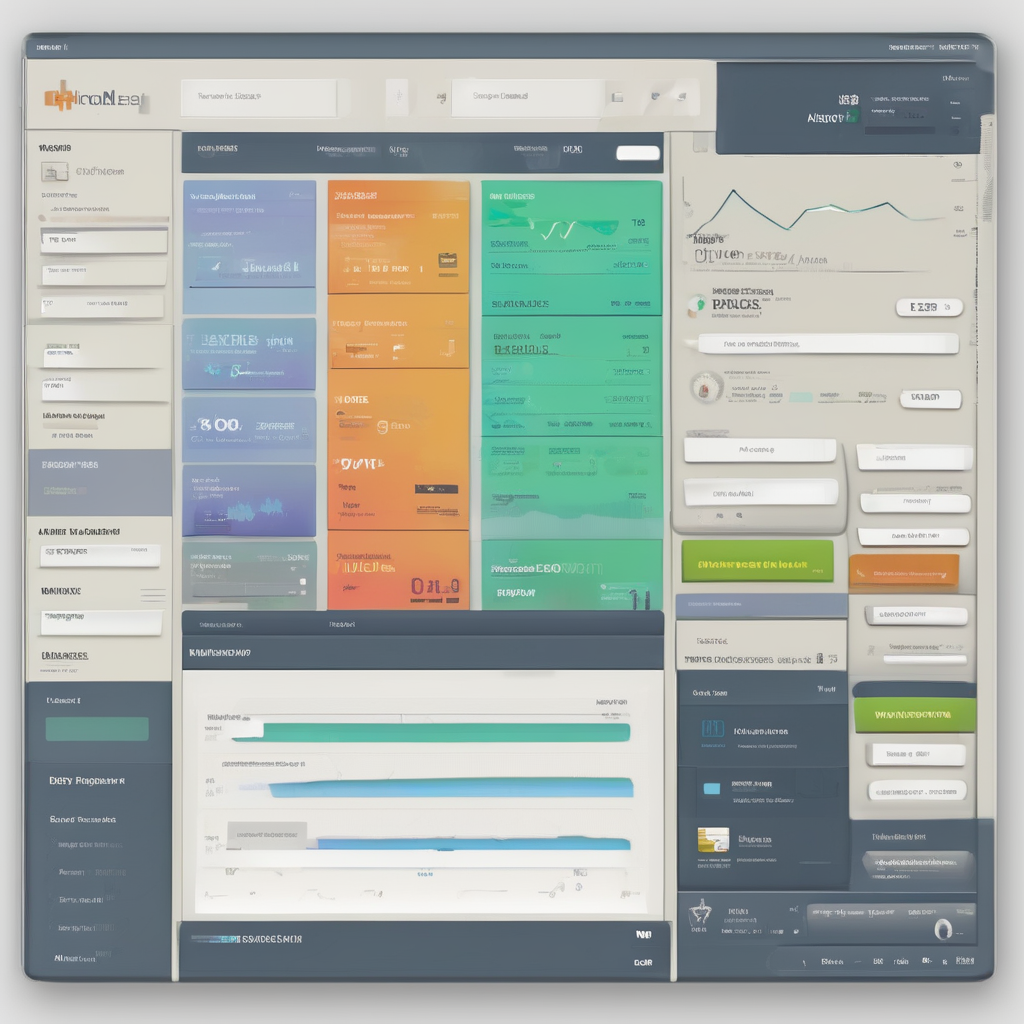

In [ ]:
# take 2
generate_image(prompt=prompt, steps=30, guidance=8.0)

  0%|          | 0/40 [00:00<?, ?it/s]

/home/dante/code/coursework/seis-606-vibe/.venv/lib/python3.14/site-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


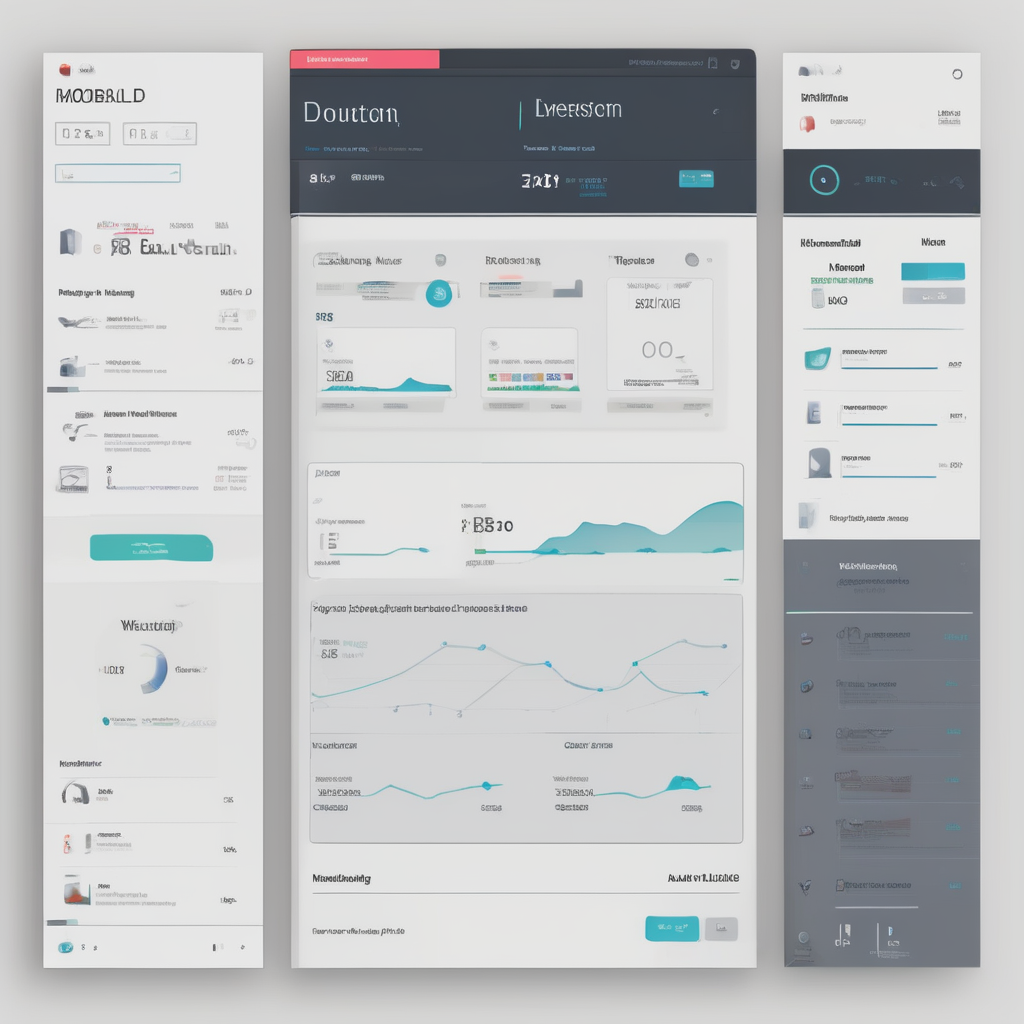

In [ ]:
# take 3
generate_image(prompt=prompt, steps=25, guidance=6.5)